In [39]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages
import gsw  # Gibbs SeaWater (TEOS-10) oceanographic toolbox for seawater property calculations
print('gsw version:', gsw.__version__)

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

gsw version: 3.6.21


# Water Level Data from OWLR at Veteran's Park Retention Pond

In the spreadsheet this is shown at rainfall_0001 data. 

In [52]:


# Paths & time window

data_dir  = "Data"
owlr_path = os.path.join(data_dir, "waterLevel_OWLR_VP_06152026.csv")

start_time = pd.Timestamp("2026-06-07 13:00:00")
end_time   = pd.Timestamp("2026-06-14 08:00:00")


# Load OWLR (rainfall rows only)

cols = [
    "device_id", "timestamp", "unused_1", "data_type",
    "epoch", "OWLR_value_cm", "rain_mm_raw", "col7", "col8"
]

owlr_raw = pd.read_csv(owlr_path, header=None, names=cols)

owlr_raw["timestamp"] = pd.to_datetime(owlr_raw["timestamp"], errors="coerce")
owlr_raw = owlr_raw[owlr_raw["data_type"] == "rainfall"].copy()

# Parse OWLR_value_cm directly; if missing, fall back to payload value in epoch
owlr_raw["OWLR_value_cm"] = pd.to_numeric(owlr_raw["OWLR_value_cm"], errors="coerce")
epoch_value = pd.to_numeric(
    owlr_raw["epoch"].astype(str).str.split(",").str[1],
    errors="coerce"
 )
owlr_raw["OWLR_value_cm"] = owlr_raw["OWLR_value_cm"].fillna(epoch_value)

owlr_raw["WSE_OWLR_cm"] = 860.24 - owlr_raw["OWLR_value_cm"]

owlr = owlr_raw[
    owlr_raw["timestamp"].notna()
    & (owlr_raw["timestamp"] >= start_time)
    & (owlr_raw["timestamp"] <= end_time)
] .copy()

owlr["timestamp_hour"] = owlr["timestamp"].dt.floor("h")
owlr = owlr.groupby("timestamp_hour", as_index=False)["WSE_OWLR_cm"].mean()

print(f"Window: {start_time} to {end_time}")
print(f"OWLR (rainfall) hourly points: {len(owlr)}")
print(owlr.tail())


Window: 2026-06-07 13:00:00 to 2026-06-14 08:00:00
OWLR (rainfall) hourly points: 164
         timestamp_hour  WSE_OWLR_cm
159 2026-06-14 04:00:00    715.03723
160 2026-06-14 05:00:00    715.34695
161 2026-06-14 06:00:00    714.90667
162 2026-06-14 07:00:00    715.10667
163 2026-06-14 08:00:00    715.18861


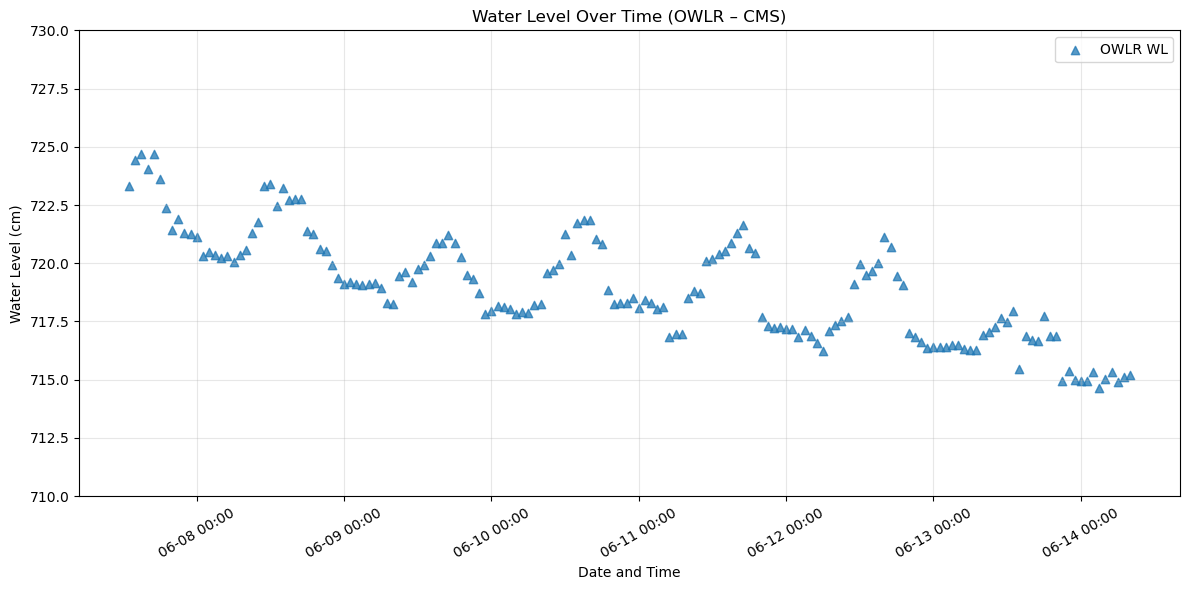

OWLR points shown: 164


In [55]:

import matplotlib.dates as mdates

owlr_plot = owlr.sort_values('timestamp_hour').copy()

plt.figure(figsize=(12, 6))

plt.scatter(
    owlr_plot['timestamp_hour'],
    owlr_plot['WSE_OWLR_cm'],
    s=36, marker='^', alpha=0.75, label='OWLR WL'
)

plt.title('Water Level Over Time (OWLR – CMS)')
plt.xlabel('Date and Time')
plt.ylabel('Water Level (cm)')
plt.ylim(710, 730)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=30)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'OWLR points shown: {len(owlr_plot)}')


In [ ]:
# Water level regression: rainfall vs rainfall_0001 within current time window
if 'owlr_path' not in globals() or 'start_time' not in globals() or 'end_time' not in globals():
    raise ValueError('Run Cell 4 first so owlr_path/start_time/end_time are defined.')

cols = [
    'device_id', 'timestamp', 'unused_1', 'data_type',
    'epoch', 'OWLR_value_cm', 'rain_mm_raw', 'col7', 'col8'
 ]

wl_raw = pd.read_csv(owlr_path, header=None, names=cols)
wl_raw['timestamp'] = pd.to_datetime(wl_raw['timestamp'], errors='coerce')
wl_raw['data_type'] = wl_raw['data_type'].astype(str).str.strip()

# Parse OWLR distance from column 6, then fallback to payload in epoch when needed
ow_val_col = pd.to_numeric(wl_raw['OWLR_value_cm'], errors='coerce')
ow_val_epoch = pd.to_numeric(
    wl_raw['epoch'].astype(str).str.split(',').str[1],
    errors='coerce'
 )
wl_raw['OWLR_value_cm'] = ow_val_col.fillna(ow_val_epoch)

wl_raw = wl_raw[
    wl_raw['timestamp'].notna()
    & wl_raw['timestamp'].between(start_time, end_time)
] .copy()

wl_subset = wl_raw[wl_raw['data_type'].isin(['rainfall', 'rainfall_0001'])].copy()
if wl_subset.empty:
    raise ValueError('No rainfall/rainfall_0001 rows found in the selected time window.')

wl_subset['WSE_OWLR_cm'] = 860.24 - wl_subset['OWLR_value_cm']
wl_subset['timestamp_hour'] = wl_subset['timestamp'].dt.floor('h')

# Hourly mean water level for each data stream
wl_hourly = (
    wl_subset.groupby(['timestamp_hour', 'data_type'], as_index=False)['WSE_OWLR_cm']
    .mean()
 )

wl_pivot = wl_hourly.pivot(
    index='timestamp_hour', columns='data_type', values='WSE_OWLR_cm'
 ).reset_index()

required_cols = {'rainfall', 'rainfall_0001'}
if not required_cols.issubset(wl_pivot.columns):
    raise ValueError('Both rainfall and rainfall_0001 are required for water-level regression.')

wl_pair = wl_pivot[['timestamp_hour', 'rainfall', 'rainfall_0001']].dropna().copy()
if len(wl_pair) < 2:
    raise ValueError('Need at least 2 paired hourly points for linear regression.')

x_wl = wl_pair['rainfall'].to_numpy(dtype=float)
y_wl = wl_pair['rainfall_0001'].to_numpy(dtype=float)
m_wl, b_wl = np.polyfit(x_wl, y_wl, 1)
y_wl_fit = m_wl * x_wl + b_wl

ss_res_wl = np.sum((y_wl - y_wl_fit) ** 2)
ss_tot_wl = np.sum((y_wl - np.mean(y_wl)) ** 2)
r2_wl = 1 - ss_res_wl / ss_tot_wl if ss_tot_wl > 0 else np.nan

print(f'Time window: {start_time} to {end_time}')
print(f'Paired hourly points: {len(wl_pair)}')
print(f'Best-fit line: WL_rainfall_0001 = {m_wl:.4f} * WL_rainfall + {b_wl:.4f}')
print(f'R^2 = {r2_wl:.4f}' if np.isfinite(r2_wl) else 'R^2 = n/a')
wl_pair.head()

Time window: 2026-06-07 13:00:00 to 2026-06-14 08:00:00
Paired hourly points: 164
Best-fit line: rainfall_0001 = 7.9021 * rainfall + 0.0274
R^2 = 0.2960


data_type,timestamp_hour,rainfall,rainfall_0001
0,2026-06-07 13:00:00,0.0,0.0
1,2026-06-07 14:00:00,0.0,0.0
2,2026-06-07 15:00:00,0.0,0.0
3,2026-06-07 16:00:00,0.0,0.0
4,2026-06-07 17:00:00,0.0,0.0


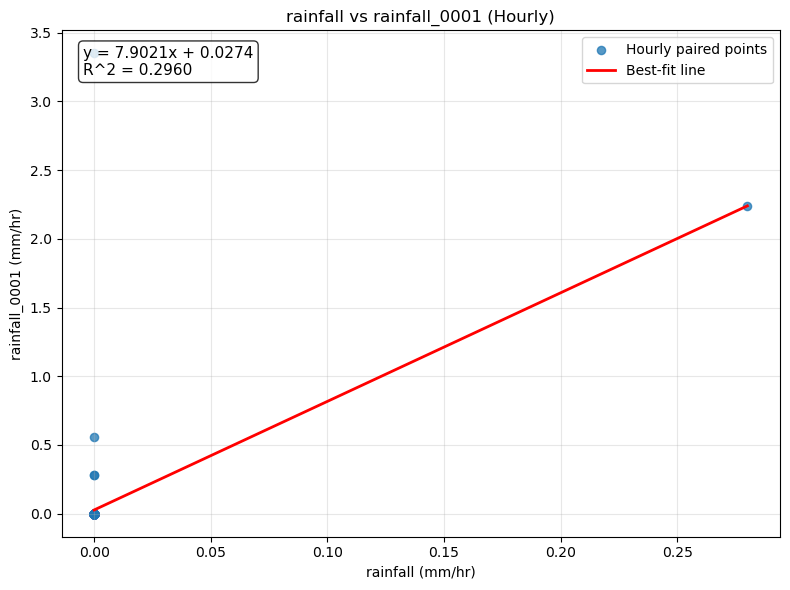

In [ ]:
# Plot water level comparison: rainfall vs rainfall_0001
if 'wl_pair' not in globals() or wl_pair.empty:
    raise ValueError('Run Cell 6 first so wl_pair is available.')

x_wl = wl_pair['rainfall'].to_numpy(dtype=float)
y_wl = wl_pair['rainfall_0001'].to_numpy(dtype=float)

plt.figure(figsize=(8, 6))
plt.scatter(x_wl, y_wl, s=35, alpha=0.75, marker='o', label='Hourly paired points')

x_line_wl = np.linspace(np.min(x_wl), np.max(x_wl), 200)
plt.plot(x_line_wl, m_wl * x_line_wl + b_wl, color='red', linewidth=2, label='Best-fit line')

plt.title('Water Level: rainfall vs rainfall_0001 (Hourly)')
plt.xlabel('Water Level from rainfall (cm)')
plt.ylabel('Water Level from rainfall_0001 (cm)')
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
ax.text(
    0.03,
    0.97,
    (f'y = {m_wl:.4f}x + {b_wl:.4f}\nR^2 = {r2_wl:.4f}' if np.isfinite(r2_wl) else f'y = {m_wl:.4f}x + {b_wl:.4f}\nR^2 = n/a'),
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
 )

plt.tight_layout()
plt.show()